In [1]:
import numpy as np
import pandas as pd
import lasio as las
from glob import glob
import matplotlib.pyplot as plt
import torch as pt
import gpytorch
import scipy
import os

from util.filehandler import read_las, save_gp_model, load_gp_model
from util.plotting import plot_well_logs, visualize_multichannel_gp_results_side_by_side, visualize_single_gp_result
from util.well_processing import filter_wells_by_lithology, prepare_valid_tagilsk
from util.gaussian_processes import fit_gp_model_all_wells, predict_gp_model

In [2]:
# las_files = glob('//mnt/Documents/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/*Tgl*.las')
las_files = glob('../data/las/*Tgl*.las')
las_files

['../data/las/Tgl-30.las',
 '../data/las/Tgl-27.las',
 '../data/las/Tgl-15.las',
 '../data/las/Tgl-26.las',
 '../data/las/Tgl-8.las',
 '../data/las/ZTgl-1.las',
 '../data/las/Tgl-29.las']

In [3]:
# Create a dictionary to store all DataFrames
las_dfs = read_las(las_files)
# Keep only needed curves
las_dfs = prepare_valid_tagilsk(las_dfs)
# Display the keys (well names) in the dictionary
# del las_dfs['ZTgl-1']
print(f"\nTotal wells loaded: {len(las_dfs)}")
print(f"Well names: {list(las_dfs.keys())}")

Loaded: Tgl-30 - 4603 rows, 14 curves
Loaded: Tgl-27 - 2377 rows, 12 curves
Loaded: Tgl-15 - 5898 rows, 14 curves
Loaded: Tgl-26 - 6062 rows, 15 curves
Loaded: Tgl-8 - 7623 rows, 16 curves
Loaded: ZTgl-1 - 5408 rows, 12 curves
Loaded: Tgl-29 - 29873 rows, 14 curves
Processing well Tgl-30
Processing well Tgl-27
Processing well Tgl-15
Processing well Tgl-26
Processing well Tgl-8
Processing well ZTgl-1
Processing well Tgl-29

Total wells loaded: 7
Well names: ['Tgl-30', 'Tgl-27', 'Tgl-15', 'Tgl-26', 'Tgl-8', 'ZTgl-1', 'Tgl-29']


/home/andrey/miniconda3/envs/nnseismic/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Processing wells, deleting trash data
### Manual trash data deletion

In [4]:
# Manual trash data deletion
# Tgl-29
mask = (las_dfs['Tgl-29']['DEPTH'] < 3700) & (las_dfs['Tgl-29']['DEPTH'] > 3000)
las_dfs['Tgl-29'].loc[mask, 'DTP'] = np.nan
mask = (las_dfs['Tgl-29']['DEPTH'] < 3700) & (las_dfs['Tgl-29']['DEPTH'] > 2398)
las_dfs['Tgl-29'].loc[mask, 'DTS'] = np.nan
# ZTgl-1
mask = (las_dfs['ZTgl-1']['DEPTH'] < 3150) & (las_dfs['ZTgl-1']['DEPTH'] > 2964)
las_dfs['ZTgl-1'].loc[mask, 'PL_GG'] = np.nan
# Tgl-8
mask = (las_dfs['Tgl-8']['DEPTH'] < 3150) & (las_dfs['Tgl-8']['DEPTH'] > 1846)
las_dfs['Tgl-8'].loc[mask, 'DTP'] = np.nan
mask = (las_dfs['Tgl-8']['DEPTH'] < 2656) & (las_dfs['Tgl-8']['DEPTH'] > 1840)
las_dfs['Tgl-8'].loc[mask, 'PL_GG'] = np.nan
# ZTgl-1
mask = (las_dfs['Tgl-27']['DEPTH'] < 3200) & (las_dfs['Tgl-27']['DEPTH'] > 1590)
las_dfs['Tgl-27'].loc[mask, 'DTP'] = np.nan
las_dfs = prepare_valid_tagilsk(las_dfs)

Processing well Tgl-30
Processing well Tgl-27
Processing well Tgl-15
Processing well Tgl-26
Processing well Tgl-8
Processing well ZTgl-1
Processing well Tgl-29


/home/andrey/miniconda3/envs/nnseismic/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
# test = las_dfs['Tgl-27'][
#     (las_dfs['Tgl-27']['DEPTH'] < 3200) & 
#     (las_dfs['Tgl-27']['DEPTH'] > 1590)
# ]

(<Figure size 850x1200 with 5 Axes>,
 array([<Axes: title={'center': 'NAS'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'LITH'}>, <Axes: title={'center': 'DTP'}>,
        <Axes: title={'center': 'DTS'}>, <Axes: title={'center': 'PL_GG'}>],
       dtype=object))

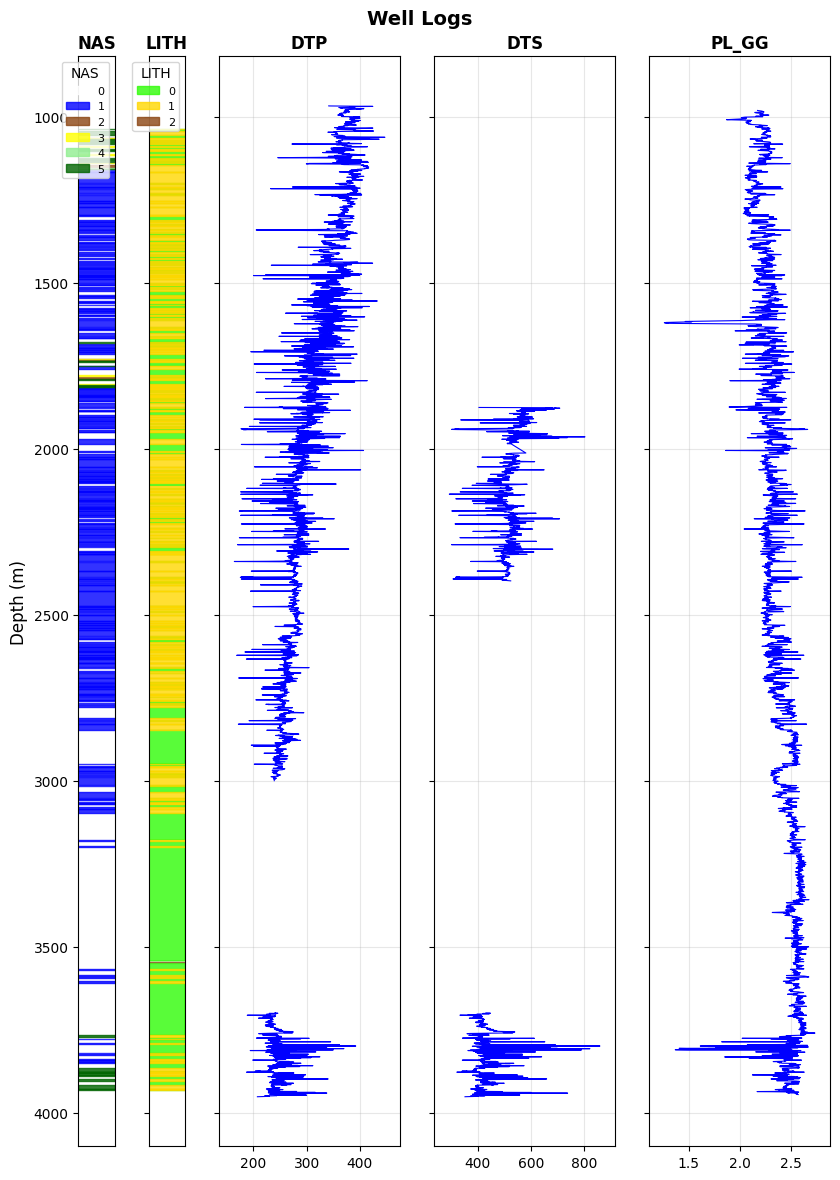

In [6]:
plot_well_logs(las_dfs['Tgl-29'], ['NAS', 'LITH', 'DTP', 'DTS', 'PL_GG'])

In [7]:
las_dfs_shale = {}
las_dfs_brine_sand = {}
las_dfs_oil_sand = {}
las_dfs_gas_sand = {}

# Apply filtering to all wells
las_dfs_shale, las_dfs_brine_sand, las_dfs_oil_sand, las_dfs_gas_sand = filter_wells_by_lithology(las_dfs)

Tgl-30: shale=2260, brine=1707, oil=142, gas=4
Tgl-27: shale=848, brine=46, oil=215, gas=34
Tgl-15: shale=2430, brine=1939, oil=427, gas=285
Tgl-26: shale=2806, brine=2255, oil=446, gas=94
Tgl-8: shale=3158, brine=723, oil=1774, gas=55
ZTgl-1: shale=2184, brine=2217, oil=0, gas=0
Tgl-29: shale=15536, brine=12102, oil=1081, gas=194


# Probabalistic models implementation

In [8]:
# from util.gaussian_processes_sklearn import fit_gp_model_sklearn
# from util.plotting import plot_gp_model

# result = fit_gp_model_sklearn(las_dfs_shale['Tgl-30'], 'VP')
# plot_gp_model(result, 'VP')

## shale

Using 29222 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']
['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: subsampled to 1000 points


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   2%|▏         | 1/50 [00:00<00:05,  8.96it/s]

Iteration 0, Loss: 1.3165


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  46%|████▌     | 23/50 [00:02<00:02, 10.99it/s]

Iteration 20, Loss: 1.1251


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  86%|████████▌ | 43/50 [00:03<00:00, 11.20it/s]

Iteration 40, Loss: 1.1092


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [00:04<00:00, 10.99it/s]


['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 1000 points


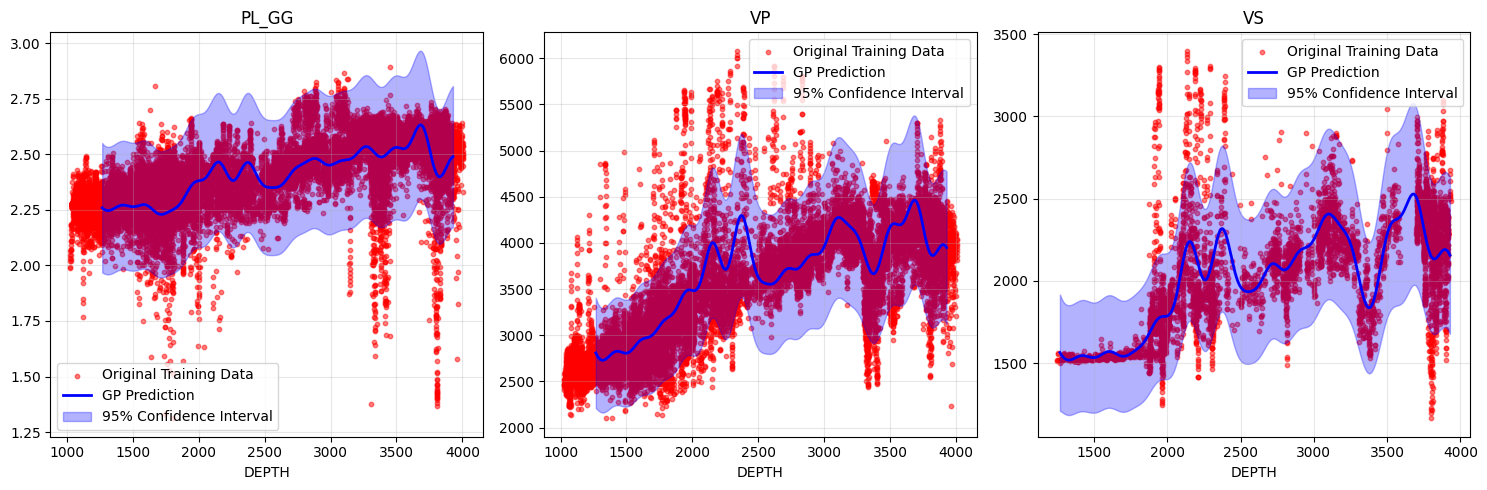

In [10]:
result = fit_gp_model_all_wells(
las_dfs_shale,
property_col=['PL_GG_LOG', 'VP_LOG', 'VS_LOG'],
max_points=1000,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_shale.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP', 'VS'], combined_df, log_transform=True)    
save_gp_model(result, f"../data/models/shale_50_iter.pth")

## brine

Using 20989 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']
['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: subsampled to 1000 points


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   2%|▏         | 1/50 [00:00<00:05,  8.84it/s]

Iteration 0, Loss: 1.2392


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  16%|█▌        | 8/50 [00:00<00:04, 10.00it/s]

Iteration 5, Loss: 1.1002


...

Iteration 40, Loss: 0.7898


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  94%|█████████▍| 47/50 [00:04<00:00, 10.42it/s]

Iteration 45, Loss: 0.7846


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [00:04<00:00, 10.25it/s]


['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 1000 points


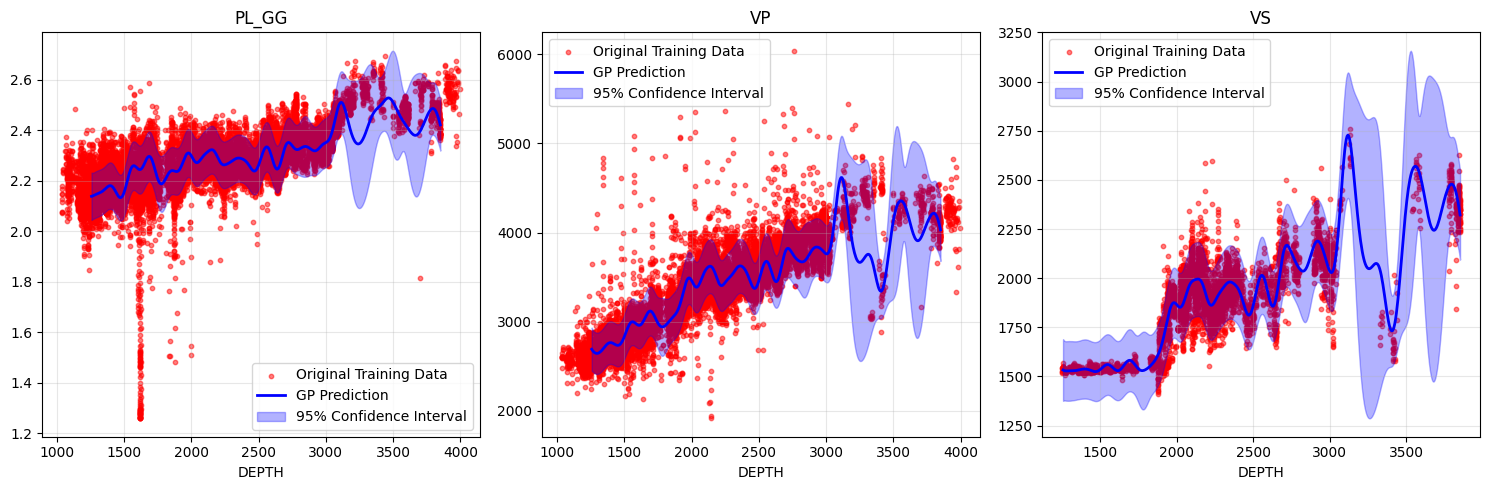

In [ ]:
result = fit_gp_model_all_wells(
las_dfs_brine_sand,
property_col=['PL_GG_LOG', 'VP_LOG', 'VS_LOG'],
max_points=1000,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_brine_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP', 'VS'], combined_df, log_transform=True)    
save_gp_model(result, f"../data/models/brine_50_iter.pth")

## oil
### PL_GG

Using 4085 total points for PL_GG_LOG


Training GP for PL_GG_LOG:   2%|▏         | 1/50 [00:00<00:05,  8.91it/s]

Iteration 0, Loss: 0.9878


Training GP for PL_GG_LOG:  54%|█████▍    | 27/50 [00:00<00:00, 44.94it/s]

Iteration 20, Loss: 0.8600


Training GP for PL_GG_LOG:  94%|█████████▍| 47/50 [00:01<00:00, 43.30it/s]

Iteration 40, Loss: 0.8316


Training GP for PL_GG_LOG: 100%|██████████| 50/50 [00:01<00:00, 42.21it/s]


PL_GG_LOG: trained on 2955 points


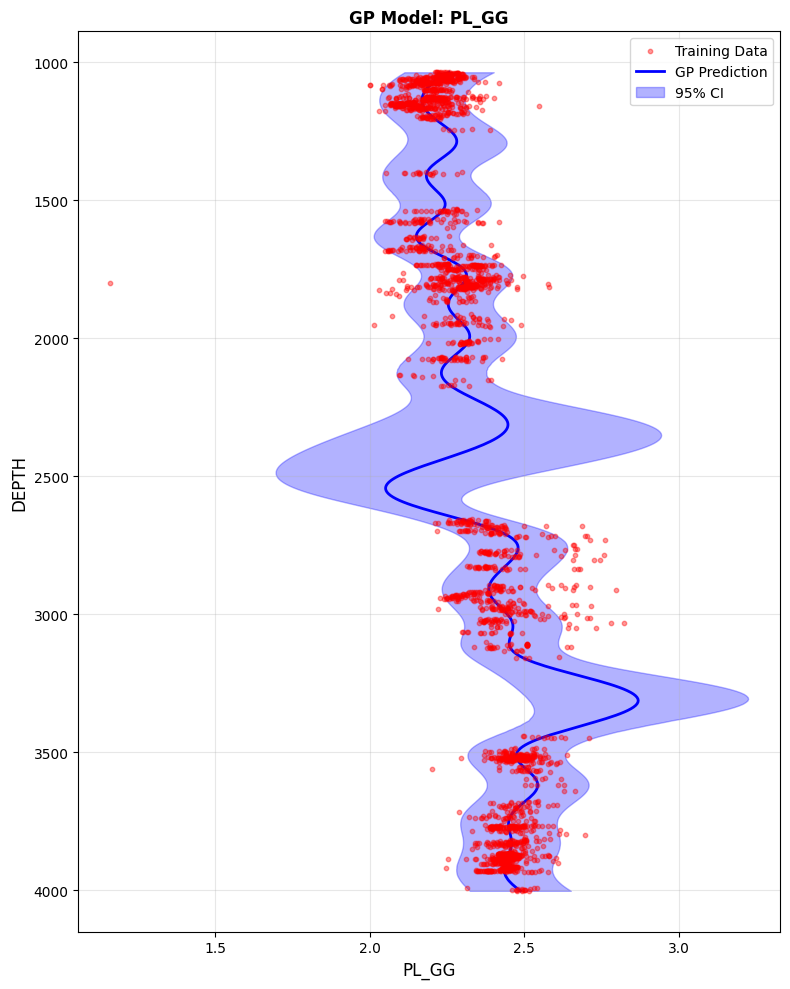

In [9]:
result = fit_gp_model_all_wells(
las_dfs_oil_sand,
property_col='PL_GG_LOG',
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_single_gp_result(result, 'PL_GG', combined_df, log_transform=True)   
save_gp_model(result, f"../data/models/oil_PL_GG_50_iter.pth")

### VS

Using 4085 total points for VS_LOG


Training GP for VS_LOG: 100%|██████████| 50/50 [00:00<00:00, 403.63it/s]

Iteration 0, Loss: 0.8588
Iteration 20, Loss: 0.3989
Iteration 40, Loss: 0.3436
VS_LOG: trained on 559 points


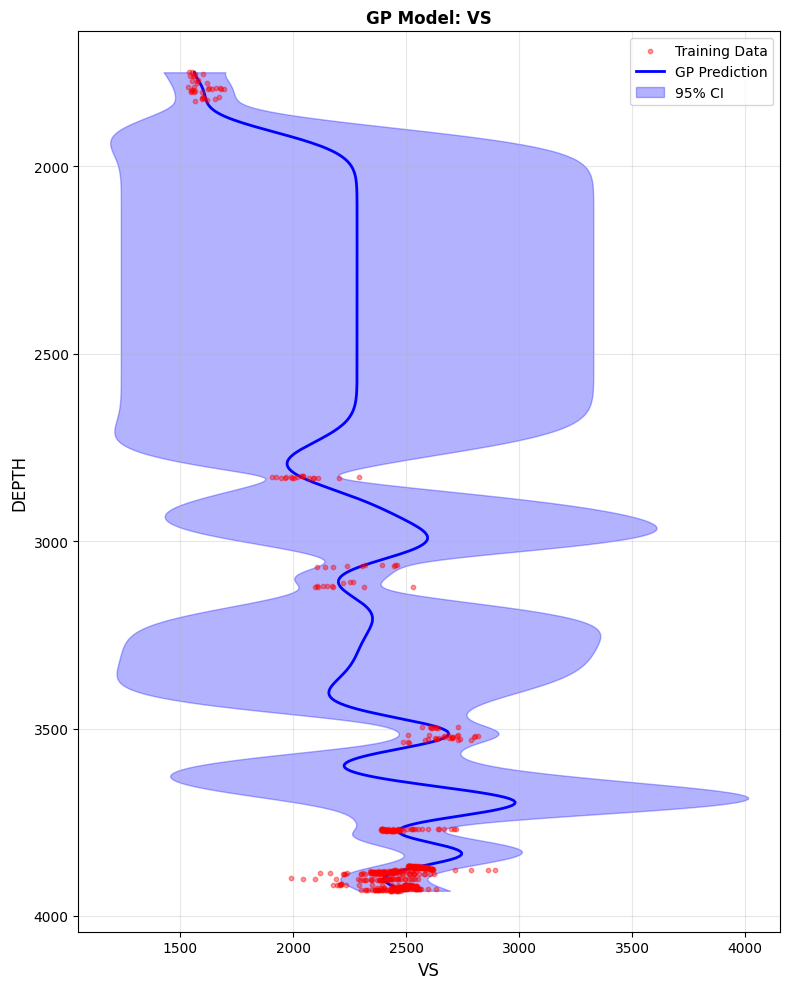

In [ ]:
result = fit_gp_model_all_wells(
las_dfs_oil_sand,
property_col='VS_LOG',
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_single_gp_result(result, 'VS', combined_df, log_transform=True)   
save_gp_model(result, f"../data/models/oil_VS_50_iter.pth")

### VP

Using 4085 total points for VP_LOG


Training GP for VP_LOG:  14%|█▍        | 7/50 [00:00<00:00, 59.76it/s]

Iteration 0, Loss: 0.8128


Training GP for VP_LOG:  62%|██████▏   | 31/50 [00:00<00:00, 52.85it/s]

Iteration 20, Loss: 0.2505


Training GP for VP_LOG: 100%|██████████| 50/50 [00:00<00:00, 51.40it/s]

Iteration 40, Loss: 0.1885
VP_LOG: trained on 2349 points


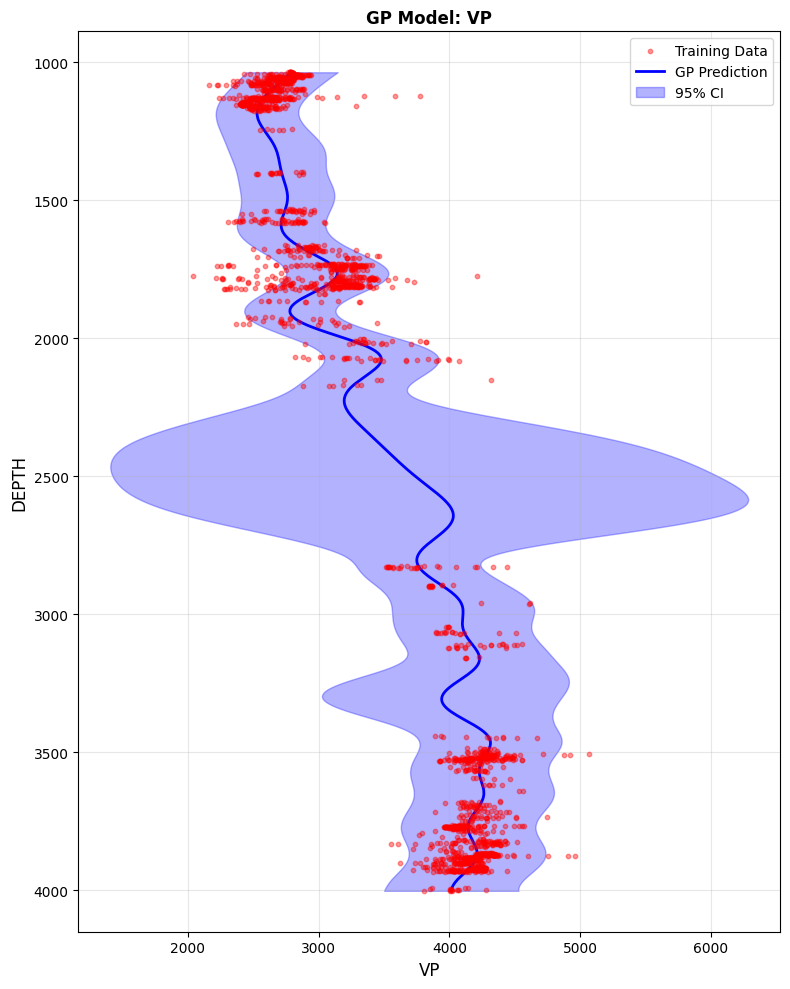

In [ ]:
result = fit_gp_model_all_wells(
las_dfs_oil_sand,
property_col='VP_LOG',
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_single_gp_result(result, 'VP', combined_df, log_transform=True)
save_gp_model(result, f"../data/models/oil_VP_50_iter.pth")

### Combined?

Using 4085 total points for ['PL_GG_LOG', 'VP_LOG']


Training GP for ['PL_GG_LOG', 'VP_LOG']:   2%|▏         | 1/50 [00:00<00:30,  1.60it/s]

Iteration 0, Loss: 1.1504


Training GP for ['PL_GG_LOG', 'VP_LOG']:  42%|████▏     | 21/50 [00:12<00:17,  1.61it/s]

Iteration 20, Loss: 0.5565


Training GP for ['PL_GG_LOG', 'VP_LOG']:  82%|████████▏ | 41/50 [00:24<00:05,  1.59it/s]

Iteration 40, Loss: 0.4204


Training GP for ['PL_GG_LOG', 'VP_LOG']: 100%|██████████| 50/50 [00:30<00:00,  1.65it/s]


['PL_GG_LOG', 'VP_LOG']: trained on 2347 points


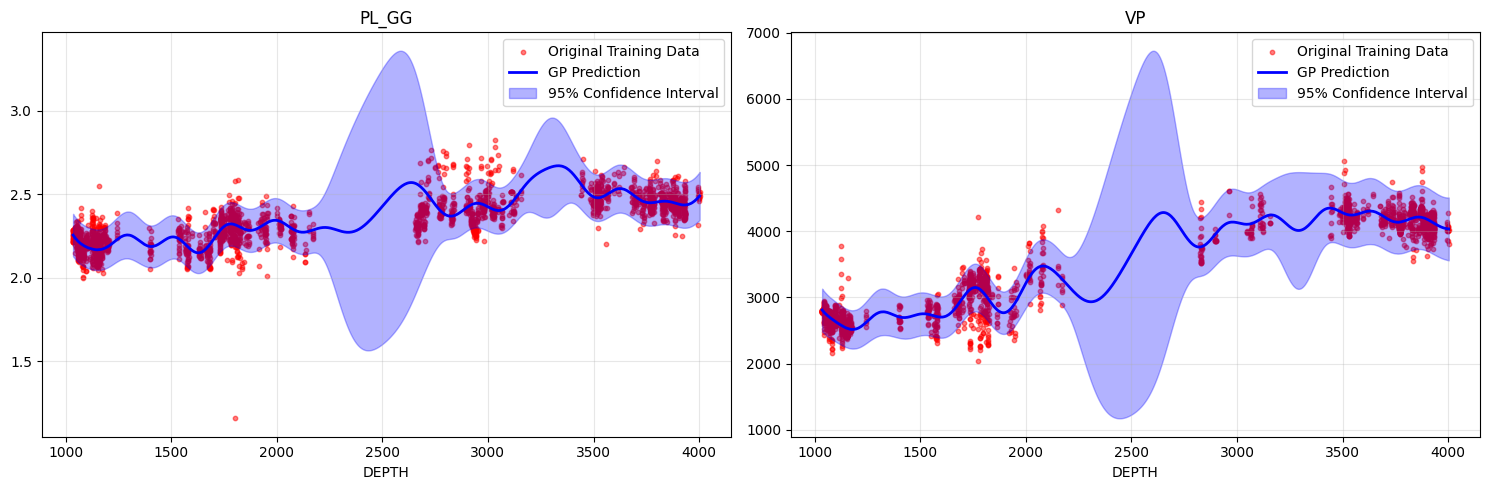

In [15]:
result = fit_gp_model_all_wells(
las_dfs_oil_sand,
property_col=['PL_GG_LOG', 'VP_LOG'],
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP'], combined_df, log_transform=True)  

Looks like shit but whatever

### Joint destribution for sampling?

In [27]:
def conditional_sample_vs(vp_val, density_val, mean, cov, n_samples=1):
    """
    Сэмплирование VS при известных VP и плотности.
    
    Partition: z = [VS, VP, PL_GG], где z1=VS (индексируем как 0), 
    z2=[VP, PL_GG] (индексы 1,2)
    """
    # Индексы: 0=VS, 1=VP, 2=PL_GG
    idx_unknown = [0]      # VS
    idx_known = [1, 2]     # VP, PL_GG
    
    # Разбиение вектора средних
    mu_unk = mean[idx_unknown]
    mu_known = mean[idx_known]
    
    # Разбиение ковариационной матрицы
    cov_unk_unk = cov[np.ix_(idx_unknown, idx_unknown)]  # Σ11
    cov_unk_known = cov[np.ix_(idx_unknown, idx_known)]  # Σ12
    cov_known_known = cov[np.ix_(idx_known, idx_known)]  # Σ22
    
    # Коэффициенты регрессии: β = Σ12 * Σ22⁻¹
    beta = cov_unk_known @ np.linalg.inv(cov_known_known)
    
    # Условное среднее: μ̂ = μ1 + β*(z2 - μ2)
    z_known = np.array([vp_val, density_val])
    cond_mean = mu_unk + beta @ (z_known - mu_known)
    
    # Условная ковариация: Σ̂ = Σ11 - β*Σ22*βᵀ
    cond_cov = cov_unk_unk - beta @ cov_known_known @ beta.T
    
    # Сэмплирование из одномерного нормального распределения
    return np.random.normal(loc=cond_mean[0], scale=np.sqrt(cond_cov[0, 0]), size=n_samples)

In [ ]:
all_data = []
for well_name, data in las_dfs_oil_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
df_known = combined_df.dropna()
mean_vec = np.mean(complete_data, axis=0)  # [μ_VP, μ_VS, μ_PL]
cov_matrix = np.cov(complete_data, rowvar=False)  # 3x3 матрица

,DEPTH,VP,VS,PL_GG
0,1057.018799,2762.077472,NaN,2.194922
1,1057.628418,2761.208858,NaN,2.177035
2,1058.237915,2753.499140,NaN,2.206832
3,1058.847656,2756.256904,NaN,2.156417
4,1059.457153,2734.827251,NaN,2.175166
...,...,...,...,...
4080,3932.500000,4126.791539,2441.758057,2.470000
4081,3932.600098,4148.912901,2428.434082,2.498000
4082,3932.699951,4193.681054,2430.623963,2.511000
4083,3932.800049,4239.425871,2432.811837,2.525000


In [31]:
combined_df.to_numpy()

array([[1.05701880e+03, 2.76207747e+03,            nan, 2.19492197e+00],
       [1.05762842e+03, 2.76120886e+03,            nan, 2.17703485e+00],
       [1.05823791e+03, 2.75349914e+03,            nan, 2.20683193e+00],
       ...,
       [3.93269995e+03, 4.19368105e+03, 2.43062396e+03, 2.51099992e+00],
       [3.93280005e+03, 4.23942587e+03, 2.43281184e+03, 2.52500010e+00],
       [3.93289990e+03, 4.29250863e+03, 2.45981279e+03, 2.52099991e+00]],
      shape=(4085, 4))

In [ ]:
from scipy.stats import multivariate_normal

complete_data = np.column_stack([vp_known, vs_known, density_known])

# Оценка среднего и ковариации
mean_vec = np.mean(complete_data, axis=0)  # [μ_VP, μ_VS, μ_PL]
cov_matrix = np.cov(complete_data, rowvar=False)  # 3x3 матрица

## gas

In [20]:
result = fit_gp_model_all_wells(
las_dfs_gas_sand,
property_col='VS_LOG',
max_points=None,
training_iter=50,
lengthscale=0.1
)
all_data = []
for well_name, data in las_dfs_gas_sand.items():
    app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_single_gp_result(result, 'VS', combined_df, log_transform=True)

Using 666 total points for VS_LOG


TypeError: 'NoneType' object is not subscriptable

Using 29222 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']
['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: subsampled to 1000 points


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   0%|          | 0/50 [00:00<?, ?it/s]

Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   2%|▏         | 1/50 [00:00<00:05,  9.11it/s]

Iteration 0, Loss: 1.3182


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  16%|█▌        | 8/50 [00:00<00:04, 10.02it/s]

...

Iteration 40, Loss: 1.1090


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  96%|█████████▌| 48/50 [00:04<00:00, 10.11it/s]

Iteration 45, Loss: 1.1072


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [00:04<00:00, 10.04it/s]


['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 1000 points


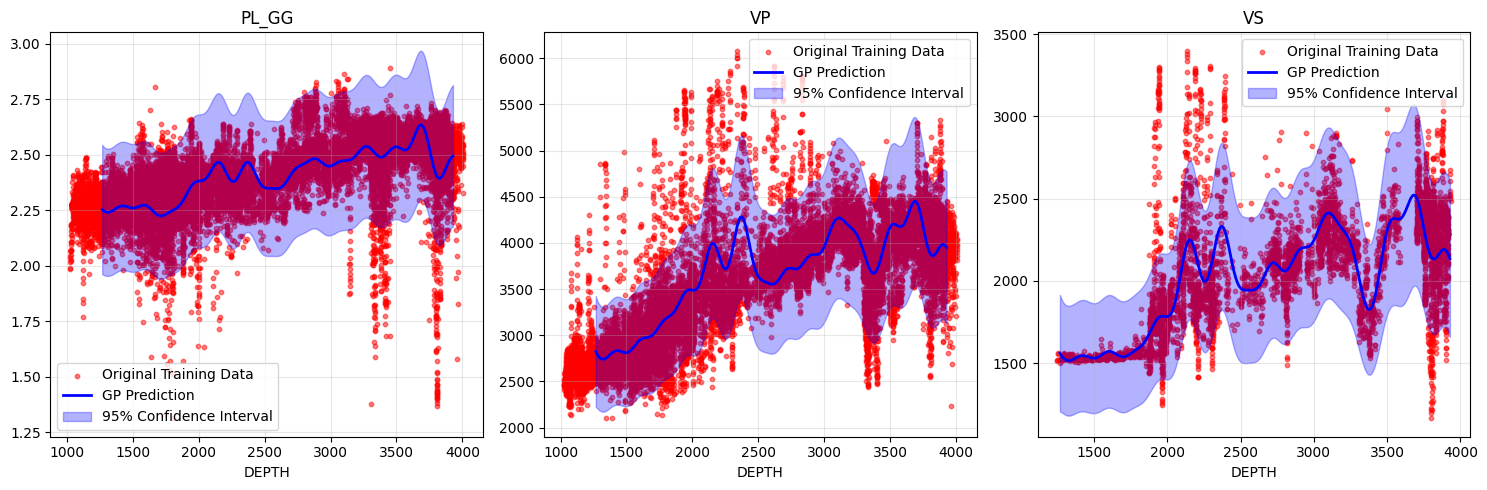

Using 20989 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']
['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: subsampled to 1000 points


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   4%|▍         | 2/50 [00:00<00:04, 10.25it/s]

Iteration 0, Loss: 1.2445


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  16%|█▌        | 8/50 [00:00<00:04, 10.29it/s]

Iteration 5, Loss: 1.1024


...

Iteration 40, Loss: 0.7937


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  96%|█████████▌| 48/50 [00:04<00:00, 10.98it/s]

Iteration 45, Loss: 0.7877


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [00:04<00:00, 10.54it/s]


['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 1000 points


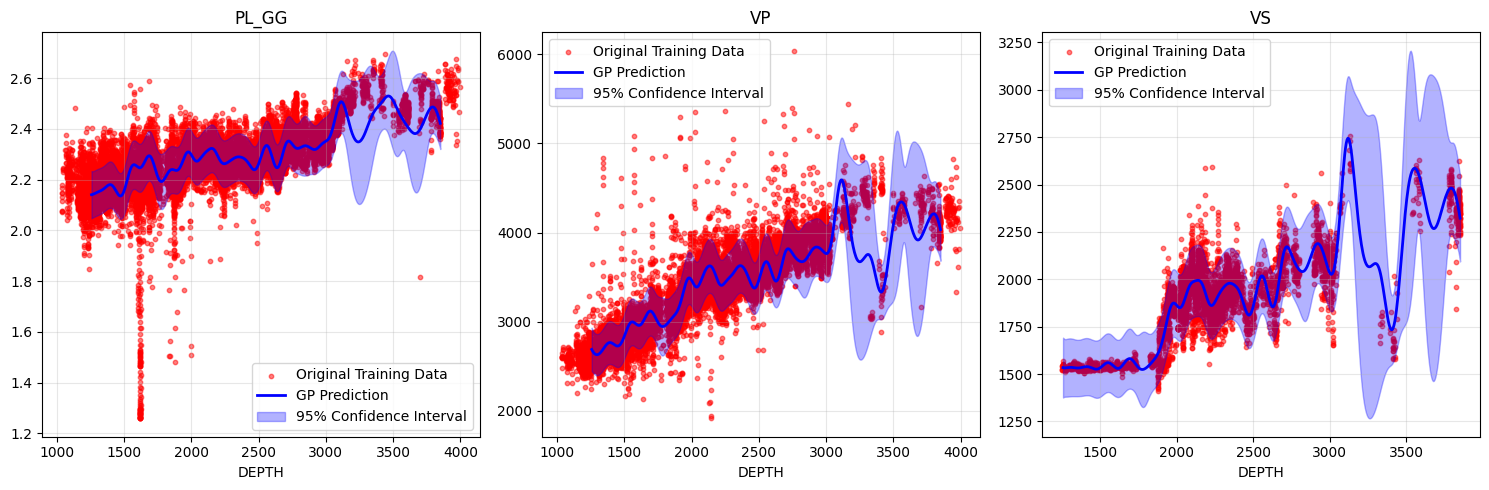

Using 4085 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   6%|▌         | 3/50 [00:00<00:02, 22.43it/s]

Iteration 0, Loss: 1.2417


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  18%|█▊        | 9/50 [00:00<00:01, 22.49it/s]

Iteration 5, Loss: 1.0929


...

Iteration 35, Loss: 0.7060


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  90%|█████████ | 45/50 [00:02<00:00, 21.53it/s]

Iteration 40, Loss: 0.6825


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [00:02<00:00, 21.98it/s]

Iteration 45, Loss: 0.6642
['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 559 points


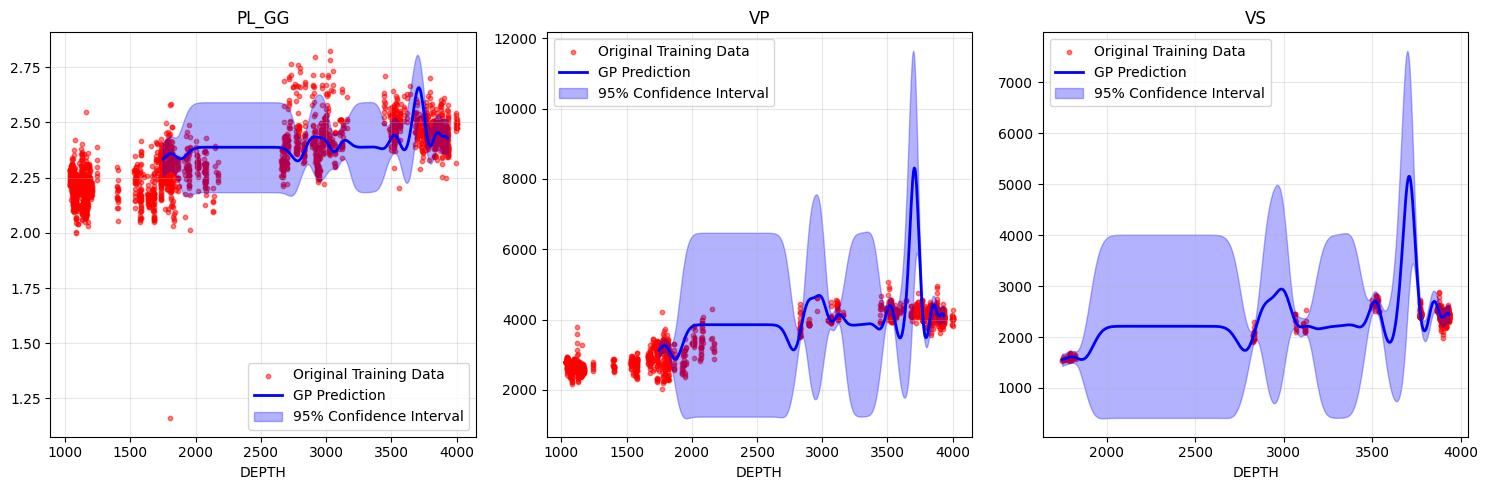

Using 666 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']


TypeError: 'NoneType' object is not subscriptable

In [ ]:
for df, name, mp in zip([las_dfs_shale, las_dfs_brine_sand, las_dfs_oil_sand, las_dfs_gas_sand],
                    ['shale', 'brine-sand', 'oil-sand', 'gas_sand'],
                    [1000, 1000, None, 666]):
    result = fit_gp_model_all_wells(
    df,
    property_col=['PL_GG_LOG', 'VP_LOG', 'VS_LOG'],
    max_points=mp,
    training_iter=50,
    lengthscale=0.1
    )
    all_data = []
    for well_name, data in df.items():
        app_data = data[['DEPTH', 'VP', 'VS', 'PL_GG']]
        all_data.append(app_data)
    combined_df = pd.concat(all_data, ignore_index=True)
    visualize_multichannel_gp_results_side_by_side(result, ['PL_GG', 'VP', 'VS'], combined_df, log_transform=True)    
    save_gp_model(result, f"../data/models/{name}_50_iter.pth")

In [ ]:
result_shale = fit_gp_model_all_wells(
    las_dfs_shale,
    property_col=['PL_GG_LOG', 'VP_LOG', 'VS_LOG'],
    max_points=5000,
    training_iter=50,
    lengthscale=0.1
)

Using 29222 total points for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']
['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: subsampled to 5000 points


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:   2%|▏         | 1/50 [00:05<04:10,  5.11s/it]

Iteration 0, Loss: 1.3214


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  12%|█▏        | 6/50 [00:30<03:49,  5.22s/it]

Iteration 5, Loss: 1.2303


...

Iteration 40, Loss: 0.9999


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']:  92%|█████████▏| 46/50 [03:49<00:20,  5.10s/it]

Iteration 45, Loss: 0.9485


Training GP for ['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: 100%|██████████| 50/50 [04:08<00:00,  4.97s/it]

['PL_GG_LOG', 'VP_LOG', 'VS_LOG']: trained on 5000 points


In [ ]:
for well_name, df in las_dfs_oil_sand.items():
    app_data = df[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)


In [19]:
save_gp_model(result_shale, "../data/models/shale_v1_50_iter.pth")

GP model saved to ../data/models/shale_v1_50_iter.pth


In [14]:
x_new = np.linspace(result_test['depth_range'][0], result_test['depth_range'][1], 500)
means, stds = predict_gp_model(result_test, x_new)

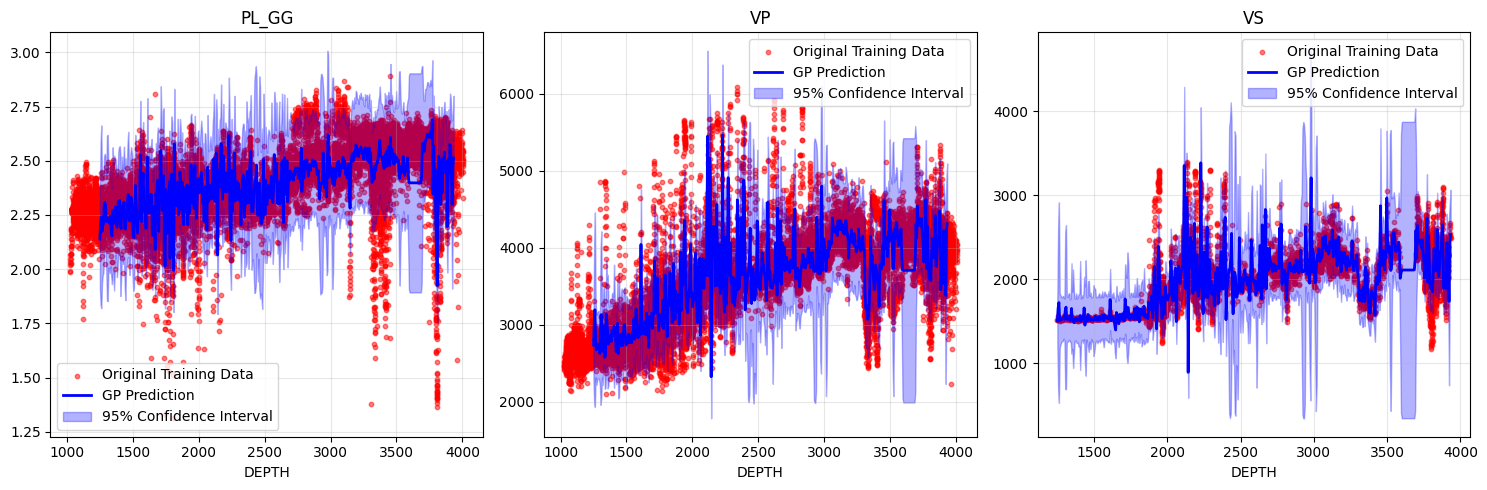

In [ ]:
all_data = []
for well_name, df in las_dfs_shale.items():
    app_data = df[['DEPTH', 'VP', 'VS', 'PL_GG']]
    all_data.append(app_data)
combined_df = pd.concat(all_data, ignore_index=True)
visualize_multichannel_gp_results_side_by_side(result_shale, ['PL_GG', 'VP', 'VS'], combined_df, log_transform=True)    

In [39]:
from util.gaussian_processes import MultitaskGPModel
def save_gp_model(gp_result, filepath):
    """
    Save a GP model and its associated components to a file using PyTorch.
    
    Args:
        gp_result: Dictionary containing the GP model and related components
                   Expected keys: 'model', 'likelihood', 'scaler_x', 'scaler_y', 'depth_range'
        filepath: Path where the model should be saved
    """
    # Get the hyperparameters from the model
    model = gp_result['model']
    
    # Prepare the state dictionary with all necessary parameters
    state_dict = {
        'model_state_dict': model.state_dict(),
        'likelihood_state_dict': gp_result['likelihood'].state_dict(),
        'model_type': type(model).__name__,
        'num_tasks': getattr(model, 'num_tasks', 1),
        'scaler_x': gp_result['scaler_x'],
        'scaler_y': gp_result['scaler_y'],
        'depth_range': gp_result['depth_range']
    }
    
    # Save the state dictionary
    pt.save(state_dict, filepath)
    print(f"GP model saved to {filepath}")

save_gp_model(result_shale, '../data/models/shale_v1.pth')

GP model saved to ../data/models/shale_v1.pth


Tgl-30
Tgl-26
ZTgl-1
Tgl-15
Tgl-29
Tgl-8
Tgl-27


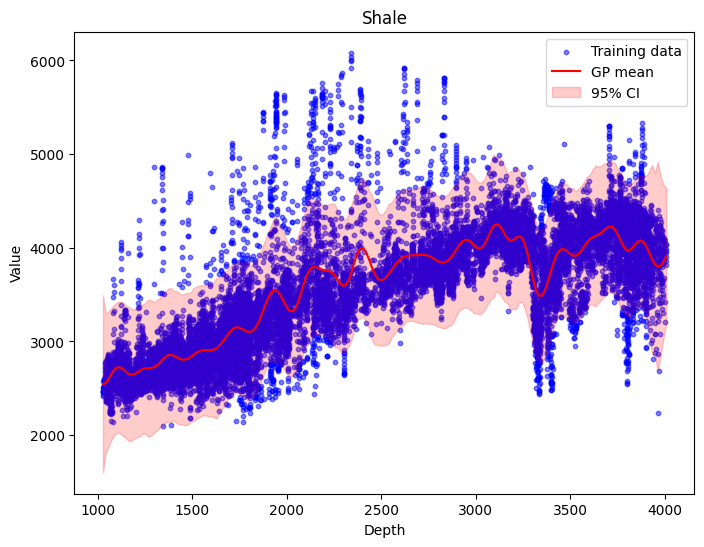

In [13]:
def plot_gp_result(gp_result: dict, x_train: np.ndarray, y_train: np.ndarray, title: str = None):
    """
    Simple plot of GP results with training data and uncertainty.
    
    Parameters
    ----------
    gp_result : dict
        Result from fit_gp_model()
    x_train : array
        Training depth values
    y_train : array
        Training property values
    title : str, optional
        Plot title
    """
    # Predict on smooth range
    x_range = np.linspace(gp_result['depth_range'][0], gp_result['depth_range'][1], 200)
    mean, std = predict_gp_model(gp_result, x_range)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x_train, y_train, c='blue', s=10, alpha=0.5, label='Training data')
    plt.plot(x_range, mean, 'r-', label='GP mean')
    plt.fill_between(x_range, mean - 2*std, mean + 2*std, alpha=0.2, color='red', label='95% CI')
    plt.xlabel('Depth')
    plt.ylabel('Value')
    if title:
        plt.title(title)
    plt.legend()
    plt.show()
all_data = []
    
for well_name, df in las_dfs_shale.items():
    app_data = df[['DEPTH', 'VP']]
    all_data.append(app_data)
    print(well_name)
combined_df = pd.concat(all_data, ignore_index=True)
plot_gp_result(result_shale, combined_df['DEPTH'], combined_df['VP'], title='Shale')

In [28]:
# Check what the model learned
result = result_shale['likelihood']
model = result_shale['model']

print("Model hyperparameters:")
print(f"  Lengthscale: {model.covar_module.base_kernel.lengthscale.item():.2f}")
print(f"  Output scale: {model.covar_module.outputscale.item():.2f}")
print(f"  Noise: {result.noise.item():.6f}")
print(f"  Mean constant: {model.mean_module.constant.item():.2f}")

Model hyperparameters:
  Lengthscale: 0.01
  Output scale: 4.19
  Noise: 0.308745
  Mean constant: -0.86


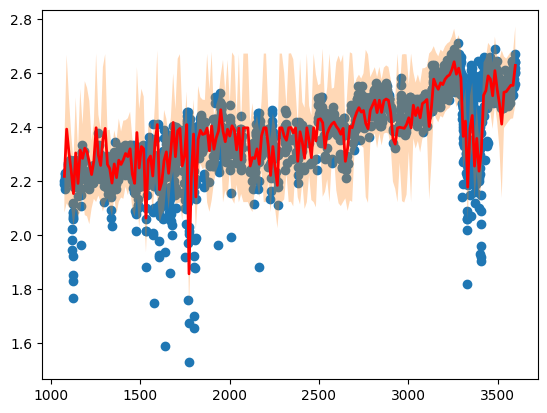

In [ ]:
x = las_dfs_shale['Tgl-15']['DEPTH']
y = las_dfs_shale['Tgl-15']['PL_GG']
x_smooth = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_mean, y_std = result['model'].predict(x_smooth, return_std=True)
plt.scatter(x, y)
plt.plot(x_smooth, y_mean, 'r-', label='GP Mean', linewidth=2)
plt.fill_between(x_smooth.flatten(), 
                y_mean - 2*y_std, 
                y_mean + 2*y_std, 
                alpha=0.3, label='±2σ')


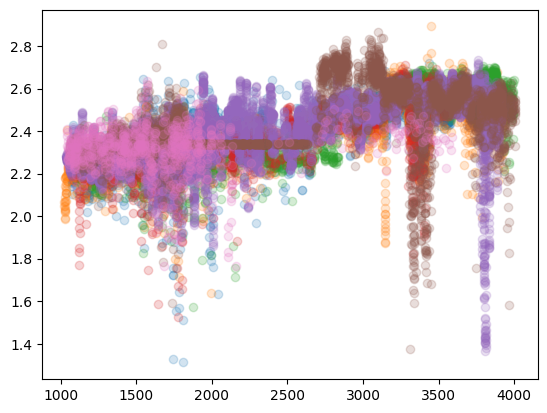

In [ ]:
for well in las_dfs_shale.keys():
    x = las_dfs_shale[well]['DEPTH']
    y = las_dfs_shale[well]['PL_GG']
    plt.scatter(x, y, alpha=0.2)